In [1]:
!pip install -q sentence-transformers scikit-learn matplotlib

In [2]:
from sentence_transformers import SentenceTransformer

# Load the free pre-trained model from Hugging Face
model = SentenceTransformer('all-MiniLM-L6-v2')

print("Model loaded successfully!")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded successfully!


In [3]:
sentence = "I love learning about Artificial Intelligence."

embedding = model.encode(sentence)

print("Sentence:", sentence)
print("Embedding shape:", embedding.shape)
print("First 10 values:", embedding[:10])

Sentence: I love learning about Artificial Intelligence.
Embedding shape: (384,)
First 10 values: [ 0.01634455 -0.0765703   0.04107474  0.01962832  0.05804764 -0.05071755
  0.03889348  0.03076576  0.05800403  0.06948569]


In [4]:
sentences = [
    "I love dogs",
    "I like puppies",
    "The stock market crashed today",
    "Cats are cute pets",
    "The economy is in recession"
]

embeddings = model.encode(sentences)

print("Number of sentences:", len(sentences))
print("Embedding matrix shape:", embeddings.shape)

Number of sentences: 5
Embedding matrix shape: (5, 384)


In [5]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(embeddings)

import pandas as pd
df = pd.DataFrame(similarity_matrix, index=sentences, columns=sentences)
df.round(2)

,I love dogs,I like puppies,The stock market crashed today,Cats are cute pets,The economy is in recession
I love dogs,1.00,0.71,0.04,0.51,0.04
I like puppies,0.71,1.00,-0.00,0.48,0.03
The stock market crashed today,0.04,-0.00,1.00,0.05,0.43
Cats are cute pets,0.51,0.48,0.05,1.00,0.06
The economy is in recession,0.04,0.03,0.43,0.06,1.00


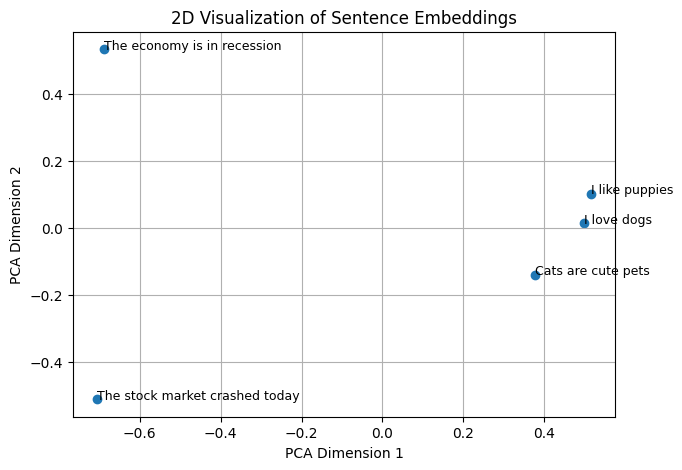

In [6]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

plt.figure(figsize=(7, 5))
plt.scatter(reduced[:, 0], reduced[:, 1])

for i, sent in enumerate(sentences):
    plt.annotate(sent, (reduced[i, 0], reduced[i, 1]), fontsize=9)

plt.title("2D Visualization of Sentence Embeddings")
plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.grid(True)
plt.show()

In [7]:
# Our small "document" database
documents = [
    "Python is a popular programming language for AI.",
    "The weather today is sunny and warm.",
    "Machine learning models learn patterns from data.",
    "I enjoy playing football on weekends.",
    "Deep learning uses neural networks with many layers.",
    "Paris is the capital city of France."
]

# Encode all documents once
doc_embeddings = model.encode(documents)

def semantic_search(query, top_k=2):
    query_embedding = model.encode([query])
    scores = cosine_similarity(query_embedding, doc_embeddings)[0]

    # Rank documents by similarity score
    ranked_idx = scores.argsort()[::-1][:top_k]

    print(f"Query: {query}\n")
    for idx in ranked_idx:
        print(f"Score: {scores[idx]:.3f}  |  {documents[idx]}")

# Try it
semantic_search("Tell me about AI and neural networks")

Query: Tell me about AI and neural networks

Score: 0.534  |  Deep learning uses neural networks with many layers.
Score: 0.524  |  Python is a popular programming language for AI.


In [8]:
semantic_search("What is the capital of France?")

Query: What is the capital of France?

Score: 0.824  |  Paris is the capital city of France.
Score: 0.102  |  Python is a popular programming language for AI.


1. Replace the `documents` list with your own 10 sentences and test `semantic_search`.

In [10]:
documents = [
    "Quantum computing utilizes the principles of superposition and entanglement.",
    "A proper diet and regular exercise are key to maintaining good health.",
    "The James Webb Space Telescope captures stunning images of distant galaxies.",
    "Making sourdough bread at home requires patience and active yeast starter.",
    "JavaScript and Python remain highly popular languages for web development.",
    "Mount Everest is the highest mountain peak above sea level in the world.",
    "Renewable energy sources like wind and solar are crucial for sustainability.",
    "Renaissance art in Italy produced legendary figures like Leonardo da Vinci.",
    "Stochastic gradient descent is a key optimization method in deep learning.",
    "Many people enjoy drinking hot coffee or tea in the early morning."
]
doc_embeddings = model.encode(documents)
print("--- Test 1 ---")
semantic_search("How to stay fit and healthy?")

print("\n--- Test 2 ---")
semantic_search("programming and building websites")

print("\n--- Test 3 ---")
semantic_search("stars, planets, and space exploration")

--- Test 1 ---
Query: How to stay fit and healthy?

Score: 0.572  |  A proper diet and regular exercise are key to maintaining good health.
Score: 0.121  |  Renewable energy sources like wind and solar are crucial for sustainability.

--- Test 2 ---
Query: programming and building websites

Score: 0.559  |  JavaScript and Python remain highly popular languages for web development.
Score: 0.149  |  Making sourdough bread at home requires patience and active yeast starter.

--- Test 3 ---
Query: stars, planets, and space exploration

Score: 0.298  |  The James Webb Space Telescope captures stunning images of distant galaxies.
Score: 0.212  |  Renewable energy sources like wind and solar are crucial for sustainability.


2. Try a different free model: `'all-mpnet-base-v2'` (more accurate, slightly slower) and compare results.

In [13]:
doc_embeddings_mpnet = model_mpnet.encode(documents)
def semantic_search_mpnet(query, top_k=2):
    query_embedding = model_mpnet.encode([query])
    scores = cosine_similarity(query_embedding, doc_embeddings_mpnet)[0]
    ranked_idx = scores.argsort()[::-1][:top_k]

    print(f"Query: {query}")
    for idx in ranked_idx:
        print(f"Score: {scores[idx]:.3f}  |  {documents[idx]}")
print("--- Test 1 (all-mpnet-base-v2) ---")
semantic_search_mpnet("How to stay fit and healthy?")

print("\n--- Test 2 (all-mpnet-base-v2) ---")
semantic_search_mpnet("programming and building websites")

print("\n--- Test 3 (all-mpnet-base-v2) ---")
semantic_search_mpnet("stars, planets, and space exploration")

--- Test 1 (all-mpnet-base-v2) ---
Query: How to stay fit and healthy?
Score: 0.658  |  A proper diet and regular exercise are key to maintaining good health.
Score: 0.043  |  Many people enjoy drinking hot coffee or tea in the early morning.

--- Test 2 (all-mpnet-base-v2) ---
Query: programming and building websites
Score: 0.611  |  JavaScript and Python remain highly popular languages for web development.
Score: 0.203  |  Quantum computing utilizes the principles of superposition and entanglement.

--- Test 3 (all-mpnet-base-v2) ---
Query: stars, planets, and space exploration
Score: 0.414  |  The James Webb Space Telescope captures stunning images of distant galaxies.
Score: 0.121  |  Renewable energy sources like wind and solar are crucial for sustainability.


3. Build a simple FAQ bot: store 5 Q&A pairs, and retrieve the best matching answer for a new question.

In [14]:
faq_database = [
    {
        "question": "How do I reset my password?",
        "answer": "To reset your password, click on the 'Forgot Password' link on the login page and follow the email instructions."
    },
    {
        "question": "What is your refund policy?",
        "answer": "We offer a full refund within 30 days of purchase. Please contact our support team with your receipt."
    },
    {
        "question": "Do you offer international shipping?",
        "answer": "Yes, we ship worldwide! Shipping times and fees vary depending on the destination country."
    },
    {
        "question": "How can I contact customer support?",
        "answer": "You can contact us via email at support@example.com or live chat on our website 24/7."
    },
    {
        "question": "Can I change or cancel my order?",
        "answer": "Orders can be changed or canceled within 1 hour of placement by visiting the 'My Orders' section in your account."
    }
]
faq_questions = [item["question"] for item in faq_database]
faq_embeddings = model.encode(faq_questions)
def get_faq_answer(user_query, threshold=0.3):
    query_embedding = model.encode([user_query])
    scores = cosine_similarity(query_embedding, faq_embeddings)[0]
    best_match_idx = scores.argmax()
    best_score = scores[best_match_idx]

    print(f"User Query: {user_query}")
    print(f"Best Match Question: {faq_questions[best_match_idx]} (Score: {best_score:.3f})")

    if best_score >= threshold:
        print(f"Answer: {faq_database[best_match_idx]['answer']}\n")
    else:
        print("Answer: I'm sorry, I couldn't find a matching answer in our FAQ database.\n")
get_faq_answer("I forgot my password, how can I log back in?")
get_faq_answer("Is it possible to ship to Europe?")
get_faq_answer("I want a refund for my purchase")
get_faq_answer("What is the weather today?")

User Query: I forgot my password, how can I log back in?
Best Match Question: How do I reset my password? (Score: 0.822)
Answer: To reset your password, click on the 'Forgot Password' link on the login page and follow the email instructions.

User Query: Is it possible to ship to Europe?
Best Match Question: Do you offer international shipping? (Score: 0.640)
Answer: Yes, we ship worldwide! Shipping times and fees vary depending on the destination country.

User Query: I want a refund for my purchase
Best Match Question: What is your refund policy? (Score: 0.693)
Answer: We offer a full refund within 30 days of purchase. Please contact our support team with your receipt.

User Query: What is the weather today?
Best Match Question: Do you offer international shipping? (Score: 0.102)
Answer: I'm sorry, I couldn't find a matching answer in our FAQ database.

